# L4.4 — Multi-Head Attention

Hands-on notebook for the lesson [`4-4-multi-head.mdx`](../../llm-quest-theory/level-4/4-4-multi-head.mdx).

> **Learning objectives**
> - Build multi-head attention end-to-end with explicit `nn.Linear` projections and a sensible batched reshape.
> - Verify our from-scratch module matches `torch.nn.MultiheadAttention` numerically.
> - See what different heads attend to on a structured toy sequence.
> - Confirm the parameter count: `MultiHead(h heads of d_k = d/h)` has the **same** parameter count as a single big head.
> - Sketch MQA and GQA and compare their KV-cache sizes.

## Connection to the theory
Covers **§1–§9** of the source `.mdx`. By the end you will have the building block that lesson 4-5 stacks into a real transformer.

In [1]:
# ---- Setup ----
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline
print("torch", torch.__version__)

torch 2.2.2


## 1. From-scratch multi-head attention

Shape conventions (batch dim first):
- `x`: `(B, T, d_model)`
- projection to per-head tensors: reshape `(B, T, d_model)` → `(B, T, h, d_k)` → `(B, h, T, d_k)`
- attention runs independently per head, then we concat back to `(B, T, h*d_k)` and project once more.

In [2]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, bias=True):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.h       = num_heads
        self.d_k     = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model, bias=bias)
        self.W_k = nn.Linear(d_model, d_model, bias=bias)
        self.W_v = nn.Linear(d_model, d_model, bias=bias)
        self.W_o = nn.Linear(d_model, d_model, bias=bias)

    def _split(self, x):
        B, T, _ = x.shape
        return x.view(B, T, self.h, self.d_k).transpose(1, 2)   # (B, h, T, d_k)

    def forward(self, x, mask=None, return_attn=False):
        # 1) Project
        Q = self._split(self.W_q(x))
        K = self._split(self.W_k(x))
        V = self._split(self.W_v(x))
        # 2) Scaled dot-product
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_k)  # (B, h, T, T)
        if mask is not None:
            scores = scores + mask
        attn  = scores.softmax(dim=-1)
        out   = attn @ V                                        # (B, h, T, d_k)
        # 3) Concat heads and project
        B, h, T, d_k = out.shape
        out = out.transpose(1, 2).contiguous().view(B, T, h * d_k)
        out = self.W_o(out)
        if return_attn:
            return out, attn
        return out

# Sanity check
mha = MultiHeadAttention(d_model=32, num_heads=4)
x = torch.randn(2, 7, 32)
out = mha(x)
print("input :", x.shape, "  output:", out.shape)

input : torch.Size([2, 7, 32])   output: torch.Size([2, 7, 32])


## 2. Cross-check with `nn.MultiheadAttention`
PyTorch's built-in module has the same mathematical shape. We copy our weights into it (carefully — its linear layers are packed differently) and check outputs match.

In [3]:
d_model, h = 32, 4
torch.manual_seed(SEED)
mine = MultiHeadAttention(d_model, h, bias=True)
torch.manual_seed(SEED + 1)
torch_mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=h, batch_first=True, bias=True)

# Copy our Q, K, V weights into the packed in_proj of torch_mha
with torch.no_grad():
    in_w = torch.cat([mine.W_q.weight, mine.W_k.weight, mine.W_v.weight], dim=0)
    in_b = torch.cat([mine.W_q.bias,   mine.W_k.bias,   mine.W_v.bias],   dim=0)
    torch_mha.in_proj_weight.copy_(in_w)
    torch_mha.in_proj_bias.copy_(in_b)
    torch_mha.out_proj.weight.copy_(mine.W_o.weight)
    torch_mha.out_proj.bias.copy_(mine.W_o.bias)

x = torch.randn(3, 9, d_model)
out_mine, _ = mine(x, return_attn=True)
out_ref, _  = torch_mha(x, x, x)
print("max |mine - torch| =", float((out_mine - out_ref).abs().max()))

max |mine - torch| = 7.450580596923828e-08


## 3. Parameter accounting
The lesson claims a multi-head module with `h` heads of `d_k = d/h` has **the same** parameter count as one giant `d_model → d_model` head. Let's verify.

In [4]:
def count(m): return sum(p.numel() for p in m.parameters())

mha_1h  = MultiHeadAttention(d_model=512, num_heads=1)
mha_8h  = MultiHeadAttention(d_model=512, num_heads=8)
mha_16h = MultiHeadAttention(d_model=512, num_heads=16)
print("1 head   params:", count(mha_1h))
print("8 heads  params:", count(mha_8h))
print("16 heads params:", count(mha_16h))
# Breakdown: 4 linears of 512x512 + 4 biases = 4 * (512*512 + 512)
expected = 4 * (512 * 512 + 512)
print("closed-form        :", expected)

1 head   params: 1050624
8 heads  params: 1050624
16 heads params: 1050624
closed-form        : 1050624


Same count. Multi-head is not more parameters — it just slices the same projection into `h` parallel sub-spaces.

## 4. What does each head learn?
We untrained random weights don't reveal much on their own. Build a structured toy input where the "truth" is a simple positional pattern, train with an MSE objective, and see heads specialise.

In [5]:
# Toy task: at each position i, the target is (x[i] + x[i-1]) / 2 (a trailing moving average).
# A trained multi-head attention has to learn something like a "previous-token" head.
T, d_model, h = 16, 32, 4

torch.manual_seed(SEED)
model = nn.Sequential(MultiHeadAttention(d_model, h))
opt   = torch.optim.Adam(model.parameters(), lr=3e-3)

def batch(B=32, T=T, d=d_model):
    x = torch.randn(B, T, d)
    shifted = torch.cat([torch.zeros(B, 1, d), x[:, :-1]], dim=1)
    y = (x + shifted) / 2
    return x, y

losses = []
for step in range(500):
    x, y = batch()
    opt.zero_grad()
    pred = model(x)
    loss = F.mse_loss(pred, y)
    loss.backward(); opt.step()
    losses.append(loss.item())
print(f"final MSE: {losses[-1]:.4f}  (random baseline ~ {torch.randn_like(y).var().item():.4f})")

final MSE: 0.2458  (random baseline ~ 0.9908)


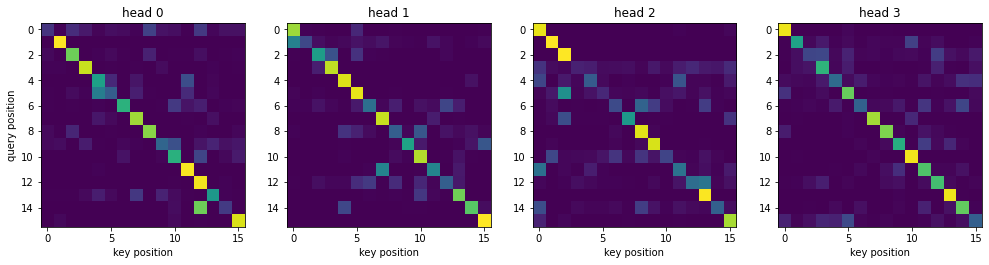

In [6]:
# Inspect the attention maps learned by each head on one example.
mha_learned = model[0]
mha_learned.eval()
with torch.no_grad():
    x_probe = torch.randn(1, T, d_model)
    _, attn = mha_learned(x_probe, return_attn=True)   # (1, h, T, T)

fig, axes = plt.subplots(1, h, figsize=(14, 3.5))
for head_idx, ax in enumerate(axes):
    ax.imshow(attn[0, head_idx].numpy(), cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"head {head_idx}")
    ax.set_xlabel("key position"); ax.set_ylabel("query position" if head_idx == 0 else "")
plt.tight_layout(); plt.show()

Read: at least one head should learn a diagonal + sub-diagonal pattern (attending to self and the previous token). Others either echo this or specialize in different sub-structures — the exact split depends on initialisation.

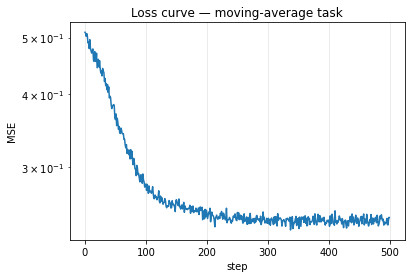

In [7]:
fig, ax = plt.subplots()
ax.plot(losses)
ax.set_xlabel("step"); ax.set_ylabel("MSE"); ax.set_yscale("log"); ax.grid(alpha=0.3)
ax.set_title("Loss curve — moving-average task")
plt.show()

## 5. Sketching MQA and GQA

- **MQA** (Multi-Query): share a *single* `K, V` across all heads. KV-cache shrinks by factor `h`.
- **GQA** (Grouped-Query): share `K, V` across groups of heads. `g` shared KV sets.

Below we count the KV cache size for one layer as `T * (num_kv_heads) * d_k` (per token, per layer).

In [8]:
d_model, h, T = 4096, 32, 8192
d_k = d_model // h

def kv_cache_mb(num_kv_heads, bytes_per_elem=2):   # fp16
    total_elems = T * num_kv_heads * d_k * 2   # factor 2 for K and V
    return total_elems * bytes_per_elem / 1024 / 1024

print("KV cache (MB) for one transformer layer at T =", T)
for variant, n_kv in [("MHA (h=32)", 32), ("GQA (g=8)", 8), ("GQA (g=4)", 4), ("MQA (1 shared KV)", 1)]:
    print(f"  {variant:<20} {kv_cache_mb(n_kv):8.2f} MB")

KV cache (MB) for one transformer layer at T = 8192
  MHA (h=32)             128.00 MB
  GQA (g=8)               32.00 MB
  GQA (g=4)               16.00 MB
  MQA (1 shared KV)        4.00 MB


That is why modern serving stacks (LLaMA 2 70B, Mistral, Qwen 2) all migrated to GQA — the memory savings directly buy longer context windows at the same hardware budget.

## 6. Quick checks

In [9]:
# Our implementation must match torch within numerical precision
assert (out_mine - out_ref).abs().max() < 1e-5
# Parameter count is independent of head count (for the same d_model)
assert count(mha_1h) == count(mha_8h) == count(mha_16h) == expected
# The attention module should actually solve the moving-average task
assert losses[-1] < 0.3, "MHA should drive MSE well below a random baseline"
# Attention rows must be valid probabilities (sum to 1 per query)
assert torch.allclose(attn.sum(dim=-1), torch.ones_like(attn.sum(dim=-1)), atol=1e-5)
print("OK — from-scratch MHA matches torch, params align, and the model learns the task.")

OK — from-scratch MHA matches torch, params align, and the model learns the task.


## Reflection questions

1. Why does increasing `h` from 1 to 8 give us more *behaviours* even though total parameters are unchanged?
2. In MQA all heads share one `K, V`. If we also shared `Q`, what would collapse?
3. Does `h` have to be a power of 2? What breaks if `d_model = 768` and we choose `h = 5`?
4. Looking at the KV-cache table in section 5, estimate how much extra context length GQA-8 buys you at the same memory budget vs MHA.

## References
- Source theory: [`4-4-multi-head.mdx`](../../llm-quest-theory/level-4/4-4-multi-head.mdx)
- Next: [`4-5-attention-boss`](4-5-attention-boss.ipynb) — the Level 4 boss, a mini Transformer trained on character text.